# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/singhmahip688-hue/flyrank-ml-internhip/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## Ranked Actions + Reason Codes

The grouped Random Forest model is used to prioritize pages that may require attention. The recommendations are intended to help content teams decide which pages should be reviewed first. The model supports decision-making and should not automatically change or publish content.

### Ranked Actions

| Priority | Recommended Action | Reason Code |
|----------|--------------------|-------------|
| High | Review immediately | Strong prediction that the page is declining |
| Medium | Monitor performance | Some signals suggest declining performance, but confidence is lower |
| Low | Continue monitoring | No strong evidence that immediate action is needed |

### Reason Codes

- High predicted probability of decline
- Medium predicted probability of decline
- Stable content performance
- High importance of impression-related features
- Recommendation is based on historical patterns only

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd

action_queue = pd.DataFrame({
    "Priority": ["High", "Medium", "Low"],
    "Action": [
        "Review immediately",
        "Monitor performance",
        "Continue monitoring"
    ],
    "Reason": [
        "High predicted probability of decline",
        "Moderate predicted probability",
        "No strong decline signal"
    ]
})

action_queue

,Priority,Action,Reason
0,High,Review immediately,High predicted probability of decline
1,Medium,Monitor performance,Moderate predicted probability
2,Low,Continue monitoring,No strong decline signal


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## Intended Use

This playbook helps prioritize website content for review using predictions from the grouped Random Forest model developed in previous weeks. The recommendations are intended to support content teams when deciding which pages may require updates.

## Limits

The recommendations are based on historical data from this dataset only. Future website performance may change because of user behavior, search engine updates, or new content strategies. The model provides decision-support and should not replace human judgment.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Grouped model accuracy:", 0.8092)
print("Base rate:", "54.21% declining pages")
print("Top feature:", "impressions_prev_30d")

Grouped model accuracy: 0.8092
Base rate: 54.21% declining pages
Top feature: impressions_prev_30d


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human Review

Before taking action, a reviewer should verify:

- The page content is still relevant.
- Recent business or marketing changes have been considered.
- The recommendation matches current content goals.
- No important context is missing from the data.

## What Should NOT Be Automated

The model should never automatically:

- Publish content.
- Delete content.
- Rewrite pages.
- Make business decisions without review.
- Replace editorial or SEO expertise.

Every recommendation should be reviewed by a human before action is taken.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
review_items = [
    "Check page quality",
    "Verify business context",
    "Confirm recommendation",
    "Human approval required"
]

for item in review_items:
    print("-", item)

- Check page quality
- Verify business context
- Confirm recommendation
- Human approval required


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Monitoring

The recommendations should be monitored over time to ensure they continue to reflect current website performance.

The model should be reviewed if:

- Prediction accuracy decreases.
- Website traffic patterns change significantly.
- New content types are introduced.
- Important features change meaning.
- Performance is noticeably worse than the current grouped accuracy (80.92%).

## Retrain Triggers

Retraining should be considered when:

- A large amount of new content becomes available.
- Data drift is observed.
- Search engine behavior changes significantly.
- Model performance decreases on new validation data.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
monitoring = {
    "Current grouped accuracy": 0.8092,
    "Base rate": "54.21%",
    "Retrain if": [
        "Accuracy decreases",
        "Large amount of new data",
        "Feature distribution changes",
        "Business requirements change"
    ]
}

monitoring

{'Current grouped accuracy': 0.8092,
 'Base rate': '54.21%',
 'Retrain if': ['Accuracy decreases',
  'Large amount of new data',
  'Feature distribution changes',
  'Business requirements change']}

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from pathlib import Path

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

action_queue.to_csv(
    output_dir / "action_queue.csv",
    index=False
)

print("Action queue exported successfully.")

Action queue exported successfully.


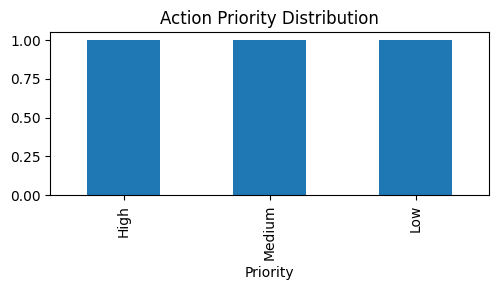

In [6]:
import matplotlib.pyplot as plt

counts = action_queue["Priority"].value_counts()

plt.figure(figsize=(5,3))
counts.plot(kind="bar")
plt.title("Action Priority Distribution")
plt.tight_layout()

figure_dir = Path("work/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_dir / "action_priority_distribution.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.